In [ ]:
import ROOT

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

ROOT.gROOT.ProcessLine('.include /usr/local/Delphes-3.4.2/')
ROOT.gROOT.ProcessLine('.include /usr/local/Delphes-3.4.2/external/')
ROOT.gInterpreter.Declare('#include "/usr/local/Delphes-3.4.2/classes/DelphesClasses.h"')
ROOT.gSystem.Load("/usr/local/Delphes-3.4.2/install/lib/libDelphes")

MAX_CONSTI = {
    'Jet': 50,
    'Tower': 250,
    'Track': 150,
    'Photon': 2,
    'Lepton': 4,
    'Photon_Za': 1,
    'Lepton_Za': 2,
}
N_CORES = 64

Welcome to JupyROOT 6.20/08


# Plot distribution

In [2]:
def Mjets(*arg):
    # arg: list of jets
    # return: invariant mass of jets
    e_tot, px_tot, py_tot, pz_tot = 0, 0, 0, 0
    
    for jet in arg:
        pt, eta, phi, m = jet[0], jet[1], jet[2], jet[3]
        
        px, py, pz = pt*np.cos(phi), pt*np.sin(phi), pt*np.sinh(eta)
        e = np.sqrt(m**2 + px**2 + py**2 + pz**2)
        
        px_tot += px
        py_tot += py
        pz_tot += pz
        e_tot += e
    
    return np.sqrt(e_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2)

In [3]:
def get_mass_and_deta(tree):
    # get invariant mass and delta eta of two leading jets
    # 1. number of photons >= 2
    # 2. number of jets >= 2
    # 3. invariant mass of two leading photons in [120, 130] GeV
    counts = [0, 0, 0]
    mass, deta = [], []
    jet_flavor = [[], []]
    for event_id, event in tqdm(enumerate(tree)):
        # if event_id == 10:
        #     break

        if event.Photon_size < 2:
            continue
        counts[0] += 1

        if event.Jet_size < 2:
            continue
        counts[1] += 1

        # compute invariant mass of two leading photons
        photons = [[event.Photon[i].PT, event.Photon[i].Eta, event.Photon[i].Phi, 0] for i in range(2)]
        maa = Mjets(*photons)
        if maa < 120 or maa > 130:
            continue
        counts[2] += 1

        jets = [[event.Jet[i].PT, event.Jet[i].Eta, event.Jet[i].Phi, event.Jet[i].Mass] for i in range(2)]
        mjj = Mjets(*jets)
        mass.append(mjj)

        detajj = np.abs(jets[0][1] - jets[1][1])
        deta.append(detajj)

        jet_flavor[0].append(event.Jet[0].Flavor)
        jet_flavor[1].append(event.Jet[1].Flavor)

    print('Total events:', event_id + 1)
    print('Events with >= 2 photons:', counts[0])
    print('Events with >= 2 jets:', counts[1])
    print('Events with maa in [120, 130] GeV:', counts[2])
    
    return mass, deta, jet_flavor

In [4]:
root_file = './MG5_samples/GGF_Higgs/Events/run_01/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')
mjj_GGF, deta_GGF, jet_flavor_GGF = get_mass_and_deta(tree)

root_file = './MG5_samples/VBF_Higgs/Events/run_01/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')
mjj_VBF, deta_VBF, jet_flavor_VBF = get_mass_and_deta(tree)

10000it [00:08, 1154.26it/s]


Total events: 10000
Events with >= 2 photons: 4788
Events with >= 2 jets: 949
Events with maa in [120, 130] GeV: 905


10000it [00:10, 929.41it/s]

Total events: 10000
Events with >= 2 photons: 5293
Events with >= 2 jets: 4257
Events with maa in [120, 130] GeV: 4059



Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Track read from file ./MG5_samples/GGF_Higgs/Events/run_01/tag_1_delphes_events.root
   has the same version (=3) as the active class but a different checksum.
   You should update the version to ClassDef(Track,4).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float C; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float Mass; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float EtaOuter; //
Warning in <TStreamerInfo::CompareContent>: The follo

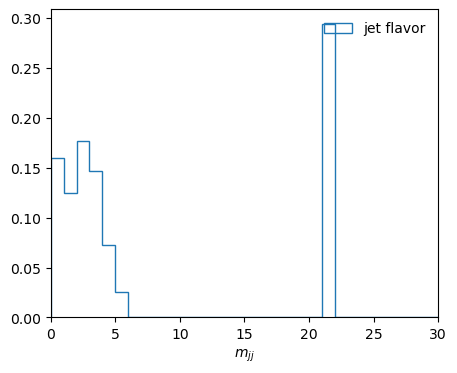

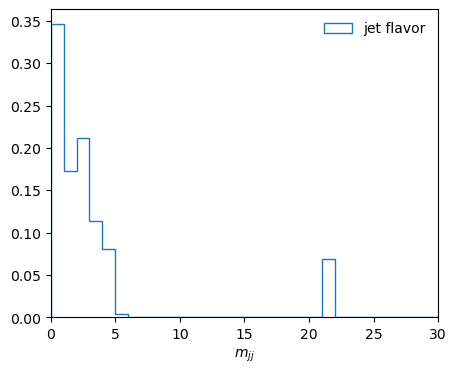

In [5]:
jet_flavor_GGF = np.array(jet_flavor_GGF)
jet_flavor_GGF = jet_flavor_GGF.flatten()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# ax.hist(jet_flavor_GGF[0], bins=30, range=[0, 30], histtype='step', label='leading jet', density=True)
# ax.hist(jet_flavor_GGF[1], bins=30, range=[0, 30], histtype='step', label='sub-leading jet', density=True)
ax.hist(jet_flavor_GGF, bins=30, range=[0, 30], histtype='step', label='jet flavor', density=True)

ax.set_xlabel('$m_{jj}$')
ax.set_xlim(0, 30)
ax.legend(frameon=False)
# plt.savefig('../figures/mjj_distribution.pdf', dpi=300, facecolor='White', bbox_inches='tight')

plt.show()

# plot jet flavor distribtuion
jet_flavor_VBF = np.array(jet_flavor_VBF)
jet_flavor_VBF = jet_flavor_VBF.flatten()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# ax.hist(jet_flavor_VBF[0], bins=30, range=[0, 30], histtype='step', label='leading jet', density=True)
# ax.hist(jet_flavor_VBF[1], bins=30, range=[0, 30], histtype='step', label='sub-leading jet', density=True)
ax.hist(jet_flavor_VBF, bins=30, range=[0, 30], histtype='step', label='jet flavor', density=True)
ax.set_xlabel('$m_{jj}$')
ax.set_xlim(0, 30)
ax.legend(frameon=False)
# plt.savefig('../figures/mjj_distribution.pdf', dpi=300, facecolor='White', bbox_inches='tight')

plt.show()

In [6]:
# find the cut such the number of GGF events in signal region and background region are equal
mjj_GGF = np.array(mjj_GGF)
mjj_VBF = np.array(mjj_VBF)
for cut in range(200, 310, 5):
    n_GGF_SR = (mjj_GGF > cut).sum() / len(mjj_GGF)
    n_GGF_BR = (mjj_GGF < cut).sum() / len(mjj_GGF)
    n_VBF_SR = (mjj_VBF > cut).sum() / len(mjj_VBF)
    n_VBF_BR = (mjj_VBF < cut).sum() / len(mjj_VBF)
    print(cut, (n_GGF_SR *32 + n_VBF_SR * 12) / (n_GGF_BR * 32 + n_VBF_BR * 12))

for cut in np.linspace(2.0, 3.0, 11):

    n_GGF_SR = (deta_GGF > cut).sum() / len(deta_GGF)
    n_GGF_BR = (deta_GGF < cut).sum() / len(deta_GGF)
    n_VBF_SR = (deta_VBF > cut).sum() / len(deta_VBF)
    n_VBF_BR = (deta_VBF < cut).sum() / len(deta_VBF)
    print(cut, (n_GGF_SR *32 + n_VBF_SR * 12) / (n_GGF_BR * 32 + n_VBF_BR * 12))

200 1.2053354614226772
205 1.1556581903348788
210 1.1105375392461203
215 1.0860434061828999
220 1.0379068005650833
225 1.0061294483853915
230 0.9750657592009357
235 0.9533427850204295
240 0.9273584253634712
245 0.9073997812931123
250 0.8926326226150312
255 0.8586808791268843
260 0.847623590065634
265 0.8310658074184926
270 0.8117181071937736
275 0.792343197590677
280 0.7776060764072419
285 0.7599901684958308
290 0.7417002594230622
295 0.7241859790531562
300 0.7019605548831787
305 0.6859961869197906
2.0 1.2800847495643937
2.1 1.1865563565519102
2.2 1.1006833050052576
2.3 1.0320415318043692
2.4 0.9597217972484398
2.5 0.8766808683291594
2.6 0.824582685645199
2.7 0.7700457048733862
2.8 0.6965975630370864
2.9 0.6480584119087938
3.0 0.5977609236732554


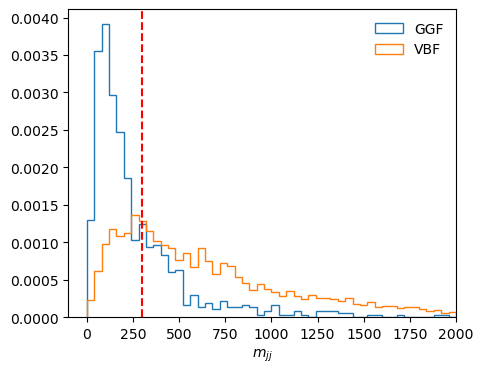

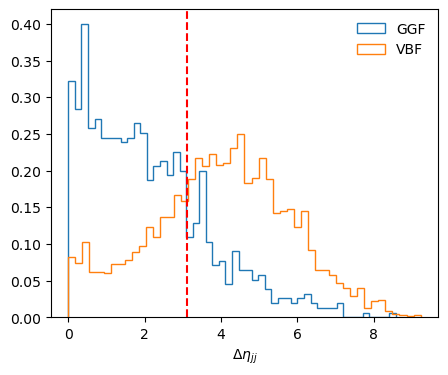

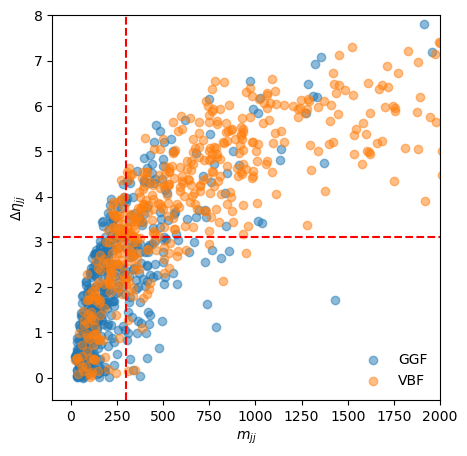

In [7]:
cuts = {'mjj': 300, 'deta': 3.1}

# plot mjj and detajj distribution
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(mjj_GGF, bins=50, range=[0, 2000], histtype='step', label='GGF', density=True)
ax.hist(mjj_VBF, bins=50, range=[0, 2000], histtype='step', label='VBF', density=True)
ax.axvline(cuts['mjj'], color='r', linestyle='--')
ax.set_xlabel('$m_{jj}$')
ax.set_xlim(-100, 2000)
ax.legend(frameon=False)
# plt.savefig('../figures/mjj_distribution.pdf', dpi=300, facecolor='White', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(deta_GGF, bins=50, histtype='step', label='GGF', density=True)
ax.hist(deta_VBF, bins=50, histtype='step', label='VBF', density=True)
ax.axvline(cuts['deta'], color='r', linestyle='--')
ax.set_xlabel('$\Delta\eta_{jj}$')
ax.legend(frameon=False)
# plt.savefig('../figures/deta_distribution.pdf', dpi=300, facecolor='White', bbox_inches='tight')
plt.show()

# plot mjj and detajj scatter plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(mjj_GGF[:500], deta_GGF[:500], marker='o', alpha=0.5, label='GGF')
ax.scatter(mjj_VBF[:500], deta_VBF[:500], marker='o', alpha=0.5, label='VBF')
ax.axvline(cuts['mjj'], color='r', linestyle='--')
ax.axhline(cuts['deta'], color='r', linestyle='--')
ax.set_xlabel('$m_{jj}$')
ax.set_ylabel('$\Delta\eta_{jj}$')
ax.set_xlim(-100, 2000)
ax.set_ylim(-0.5, 8)
ax.legend(frameon=False)
# plt.savefig('../figures/mjj_deta_scatter_plot.pdf', dpi=300, facecolor='White', bbox_inches='tight')
plt.show()

# Basic Information

In [8]:
def get_number_of_constituents(tree):

    # get invariant mass and delta eta of two leading jets
    # 1. number of photons >= 2
    # 2. number of jets >= 2
    # 3. invariant mass of two leading photons in [120, 130] GeV

    n_consti = [[], [], [], [], []]

    for event_id, event in tqdm(enumerate(tree)):
        # if event_id == 10:
        #     break

        if event.Photon_size < 2:
            continue

        if event.Jet_size < 2:
            continue

        # compute invariant mass of two leading photons
        photons = [[event.Photon[i].PT, event.Photon[i].Eta, event.Photon[i].Phi, 0] for i in range(2)]
        maa = Mjets(*photons)
        if maa < 120 or maa > 130:
            continue

        # Get number of constituents
        constituents = [consti for consti in event.Jet[0].Constituents if consti != 0]
        n_consti[0].append(len(constituents))

        constituents = [consti for consti in event.Jet[1].Constituents if consti != 0]
        n_consti[1].append(len(constituents))

        # extract all track and tower constituents
        constituents = [consti for consti in event.Tower if consti != 0]
        n_consti[2].append(len(constituents))

        constituents = [consti for consti in event.Track if consti != 0]
        n_consti[3].append(len(constituents))
    return n_consti

In [9]:
root_file = './MG5_samples/GGF_Higgs/Events/run_02/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')

n_consti = get_number_of_constituents(tree)

100000it [01:28, 1130.26it/s]


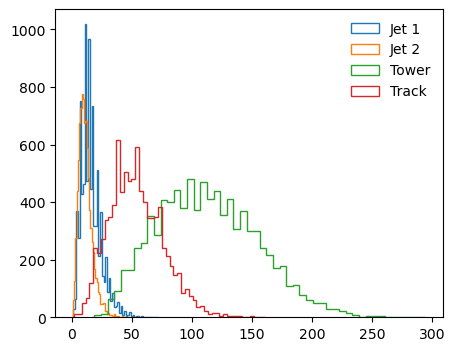

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(n_consti[0], bins=50, histtype='step', label='Jet 1')
ax.hist(n_consti[1], bins=50, histtype='step', label='Jet 2')
ax.hist(n_consti[2], bins=50, histtype='step', label='Tower')
ax.hist(n_consti[3], bins=50, histtype='step', label='Track')
ax.legend(frameon=False)
plt.show()

In [11]:
root_file = './MG5_samples/VBF_Higgs/Events/run_01/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')

n_consti_s = get_number_of_constituents(tree)

10000it [00:11, 894.39it/s]


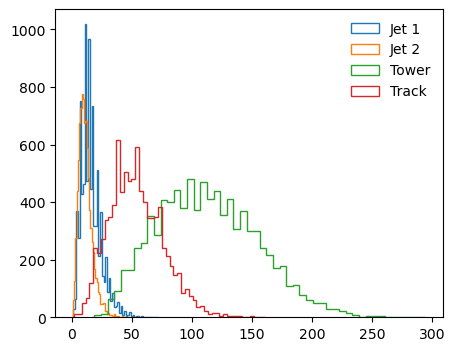

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(n_consti[0], bins=50, histtype='step', label='Jet 1')
ax.hist(n_consti[1], bins=50, histtype='step', label='Jet 2')
ax.hist(n_consti[2], bins=50, histtype='step', label='Tower')
ax.hist(n_consti[3], bins=50, histtype='step', label='Track')
ax.legend(frameon=False)
plt.show()